### Necessary Imports

In [ ]:
from astropy.table import Table, QTable
from astropy.io.votable import parse
from astroquery.gaia import Gaia
import astropy.units as u
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
import os
import pandas as pd
import pathlib

#### Now we'll use the stored rcparams.txt file to format our figure

In [6]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [7]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [8]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

## Our hot star sample is the least cooperative of all our subpopulations. Here we will try to demonstrate that for these stars, our predictions are likely spurious. We will do this by trying to compare our network inferred Prot value to a Period derived from photometric observables.

### If the star we observe has a photometric radius value (radius_val [solar radii]; from Gaia DR2) and a provided spectroscopic rotational broadening (vbroad [km/s]; from Gaia DR3), we can calculate a spectroscopic P/sin(i) as:

$$
\rm{R} \hspace{2pt} \rm{[km]} = \rm{R} \hspace{2pt} \rm{[R\odot]} * 695700
$$

$$
P_{spec} \hspace{2pt} [\frac{\rm{seconds}}{sin(i)}] = \frac{2\pi * \rm{R} \hspace{2pt} \rm{[km]}}{\rm{vbroad}}
$$

$$
P_{spec} \hspace{2pt} [\frac{\rm{days}}{sin(i)}] = P_{spec} \hspace{2pt} [\frac{\rm{seconds}}{sin(i)}] * \frac{1}{86400}

In [10]:
non_sidereal = hot[(hot['period']>28) | (hot['period'] < 22)] # first toss out any with periods at 25+/-3 for potential sidereal aliasing
dr2ids = non_sidereal['dr2_source_id'].to_list()

Gaia.MAIN_GAIA_TABLE = "gaiadr2.gaia_source" # now query the necessary Gaia information
query = f"SELECT source_id AS dr2_source_id, radius_percentile_lower, radius_percentile_upper FROM gaiadr2.gaia_source AS gsource WHERE source_id IN ({','.join(map(str, dr2ids))})"
job = Gaia.launch_job(query)
result_table = job.get_results().to_pandas().drop_duplicates(subset='dr2_source_id')

In [11]:
merged = pd.merge(non_sidereal, result_table, on='dr2_source_id', how='inner') # combine the dataframes
hasvbroad = merged.dropna(axis='rows', subset='vbroad', how='any') # drop any NaN values
good_vbroad = hasvbroad[hasvbroad['vbroad']>10] # ensure we are only including ones above the Gaia RVS noise threshold

### Now let's do our calculations and error propogation

In [13]:
as_qtable = QTable().from_pandas(good_vbroad)
radii_km = (as_qtable['radius_val']*u.solRad).to(u.km)
vbroad_kms = (as_qtable['vbroad']*u.km*(u.s**-1)).to(u.km*(u.d**-1))

numerator = 2 * np.pi * radii_km
denominator = vbroad_kms

pspec = numerator/denominator

periods = as_qtable['period'] * u.d
errors_prot = as_qtable['sigma'] * u.d
# if Z = X/Y for a variable, the uncertainty on Z is Z * sqrt((sigma_X/X) + (sigma_Y/Y))

sigma_X_up = (as_qtable['radius_percentile_upper']*u.solRad).to(u.km)
sigma_X_low = (as_qtable['radius_percentile_lower']*u.solRad).to(u.km)

sigma_Y = (as_qtable['vbroad_error']*u.km*(u.s**-1)).to(u.km*(u.d**-1))

X = radii_km
Y = vbroad_kms
Z = radii_km/vbroad_kms

sigma_Z_upper = (Z * ((sigma_X_up/X)**2 + (sigma_Y/Y)**2)**(0.5))
sigma_Z_lower = (Z * ((sigma_X_low/X)**2 + (sigma_Y/Y)**2)**(0.5))

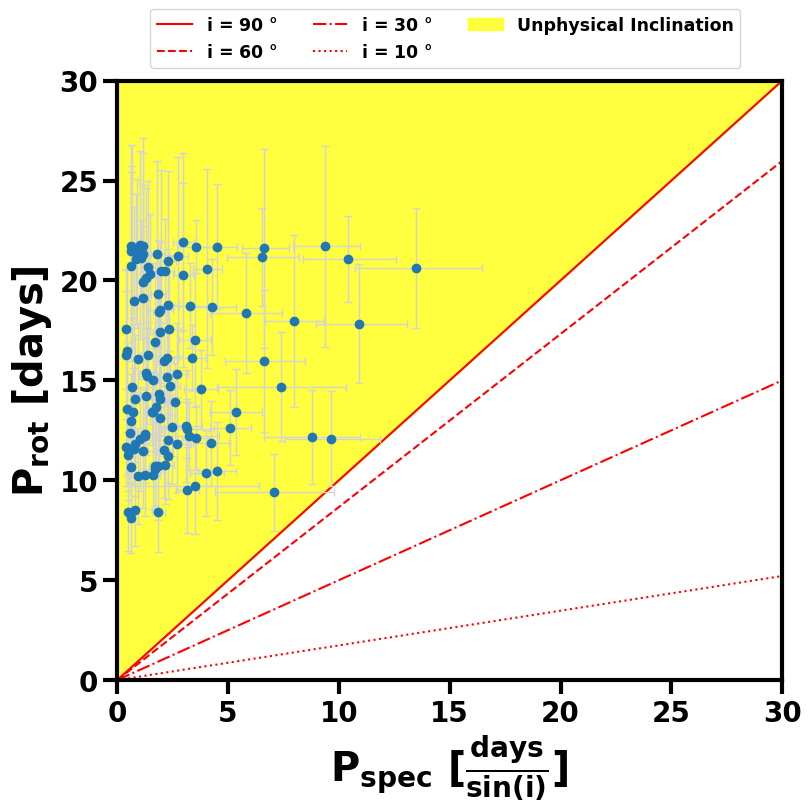

In [14]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')
axs.set(ylim=[0, 30], xlim=[0, 30], ylabel=r'P$_{\rm{rot}}$ [days]', xlabel=r'P$_{\rm{spec}}$ [$\frac{\rm{days}}{\rm{sin(i)}}$]')
t = axs.plot([0, 30], [0, 30], "r-", label="i = 90 $\degree$", rasterized=True)
axs.plot([0, 30], [0, 30*np.sin(60*np.pi*(1/180))], "r--", label="i = 60 $\degree$", rasterized=True)
axs.plot([0, 30], [0, 30*np.sin(30*np.pi*(1/180))], "r-.", label="i = 30 $\degree$", rasterized=True)
axs.plot([0, 30], [0, 30*np.sin(10*np.pi*(1/180))], "r:", label="i = 10 $\degree$", rasterized=True)
axs.fill_between([0, 30], [0, 30], y2=axs.get_ylim()[1], color='yellow', alpha=0.75, label='Unphysical Inclination', rasterized=True)
im0 = axs.errorbar(pspec.value, periods.value, yerr=errors_prot.value, xerr=(sigma_Z_lower.value, sigma_Z_upper.value), fmt='o',
             ecolor='lightgray', elinewidth=1, capsize=3, rasterized=True)
axs.legend(loc='center right', ncols=3, bbox_to_anchor=(0.95, 1.07), fontsize=12.5)